
# Versuch 1 - Entfernungsmesser mit nichtlinearer Kennlinie von 10cm bis 70cm, jeder Testvorgang jeweils im Abstand von 3cm

## Teilaufgabe 1

### Zuerst werden alle Werte gemessen und die gemessenen Mittelwerte werden protokolliert.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Vorüberlegung: Bei 10cm starten, bis 70, Abstände ohne Fehlerrechnung (ohne Blatt)
means = [1.426, 1.243, 1.107, 1.017, 0.9199, 0.8561, 0.8003, 0.7459, 0.7058, 0.6653, 0.6287,
        0.6107, 0.5698, 0.5531, 0.5268, 0.4945, 0.4732, 0.4744, 0.4567, 0.4353, 0.4189] # in V
print(means)

[1.426, 1.243, 1.107, 1.017, 0.9199, 0.8561, 0.8003, 0.7459, 0.7058, 0.6653, 0.6287, 0.6107, 0.5698, 0.5531, 0.5268, 0.4945, 0.4732, 0.4744, 0.4567, 0.4353, 0.4189]


### Nun werden alle Werte, gespeichert in den dazu korrespondierenden .csv-Dateien, eingelesen und die berechneten Mittelwerte und Standardabweichungen ausgegeben

In [47]:
means_calc = []
for i in range(10, 71, 3):
    df = pd.read_csv(f"./Versuch1-{i}.csv", sep=";", decimal=",", skiprows=range(1, 1001)) # die ersten 1000 Werte werden übersprungen
    mean = np.mean(df["Kanal A"])
    means_calc.append(mean)
    print(f"\u001b[3;35mMean for {i}cm: {mean}\u001b[0m")
    std = np.std(df["Kanal A"], ddof=1)
    print(f"\u001b[1;34mStd for {i}cm: {std}\u001b[0m\n")

Mean for 10cm: 1.426374212797604
Std for 10cm: 0.024206432348231163

Mean for 13cm: 1.242994392786465
Std for 13cm: 0.024453072105776276

Mean for 16cm: 1.1067726333219838
Std for 16cm: 0.023887853071684728

Mean for 19cm: 1.017089619412253
Std for 19cm: 0.022422589270204893

Mean for 22cm: 0.9198457115786042
Std for 22cm: 0.023539303991733915

Mean for 25cm: 0.8561134928066412
Std for 25cm: 0.022490497903436883

Mean for 28cm: 0.8002881626306221
Std for 28cm: 0.019162417148230606

Mean for 31cm: 0.7458601500799706
Std for 31cm: 0.018672695750560703

Mean for 34cm: 0.7056821248878731
Std for 34cm: 0.017480168698563083

Mean for 37cm: 0.6651259848701134
Std for 37cm: 0.020729208187213393

Mean for 40cm: 0.6286134909332703
Std for 40cm: 0.024031802334018467

Mean for 43cm: 0.6107348459273856
Std for 43cm: 0.018544449688351675

Mean for 46cm: 0.5697958044055276
Std for 46cm: 0.020499588816344054

Mean for 49cm: 0.5531183827262506
Std for 49cm: 0.021181052001600364

Mean for 52cm: 0.526868

## Teilaufgabe 2

### Um die Kennlinie, und die damit darzustellende Übertragungsfunktion, mittels linearer Regression, graphisch darstellen zu können, muss bei einem nichtlinearen Sharp-Sensor erst jeder signifikante Teil (Ein-, Aus-; Abstand, Spannung) logarithmiert werden und in Zusammenhang gebracht werden, sodass gilt:


#### $$y' = \ln y = \ln{(x^a)} = a \cdot \ln x = a \cdot \ln{(e^{x'})} = a \cdot x'$$
### und es dadurch linear wird.



### $$Bei\ x \in \{10 + 3k \mid k \in \mathbb{N}_0, 10 + 3k \leq 70 \} \land y := gemessene\ Spannungen:$$ 

#### Zuerst Numpy-Floats zur besseren Darstellung in Python-native Floats konvertieren.

In [49]:
means_calc = np.float64(means_calc)
print(means_calc)

[1.42637421 1.24299439 1.10677263 1.01708962 0.91984571 0.85611349
 0.80028816 0.74586015 0.70568212 0.66512598 0.62861349 0.61073485
 0.5697958  0.55311838 0.52686879 0.49439823 0.47321163 0.4743423
 0.45662413 0.43530759 0.41893736]


#### Nun die unterschiedlichen gemessenen und kalkulierten Messwerte graphisch darstellen, um deren Unterschiede graphisch darzustellen.

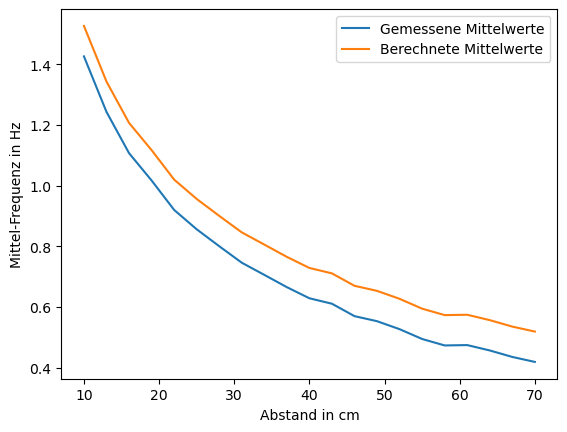

In [66]:
xs = [i for i in range(10, 71, 3)]

plt.plot(xs, means, label="Gemessene Mittelwerte")
plt.plot(xs, means_calc+0.1, label="Berechnete Mittelwerte")
plt.legend()
plt.xlabel("Abstand in cm")
plt.ylabel("Mittel-Frequenz in Hz")
plt.show()